In [1]:
pip install opencv-python


In [2]:
pip uninstall opencv-python -y

Found existing installation: opencv-python 4.8.1.78
Uninstalling opencv-python-4.8.1.78:
  Successfully uninstalled opencv-python-4.8.1.78
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install opencv-python==4.8.1.78

  Using cached opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl (38.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import cv2
import tensorflow as tf

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("OpenCV working ✅")


NumPy: 1.26.4
TensorFlow: 2.15.0
OpenCV working ✅


In [5]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import os
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from skimage.feature import hog

from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'


In [8]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels

In [9]:
import os
print(os.getcwd())

E:\Data Science\project\AMDOX AI-Powered_Task_Optimizer-main


In [10]:
TRAIN_DIR = r"C:\Users\hp\Downloads\archive (1)\train"
TEST_DIR  = r"C:\Users\hp\Downloads\archive (1)\test"

In [11]:
import os
print(os.getcwd())
print(os.listdir())

E:\Data Science\project\AMDOX AI-Powered_Task_Optimizer-main
['.ipynb_checkpoints', 'archive', 'Emotion Analysis Using Images.ipynb', 'Emotion Analysis Using Text.ipynb', 'text_emotion_analysis.pkl', 'Text_Emotion_analysis.sav', 'tweet_emotions.csv']


In [12]:
import os
print(os.listdir("archive"))

['test', 'train']


In [13]:
TRAIN_DIR = "archive/train"
TEST_DIR  = "archive/test"

import os
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))

True
True


In [14]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [15]:
print(train)

                                              image     label
0         archive/train\angry\Training_10118481.jpg     angry
1         archive/train\angry\Training_10120469.jpg     angry
2         archive/train\angry\Training_10131352.jpg     angry
3         archive/train\angry\Training_10161559.jpg     angry
4          archive/train\angry\Training_1021836.jpg     angry
...                                             ...       ...
28704  archive/train\surprise\Training_99916297.jpg  surprise
28705  archive/train\surprise\Training_99924420.jpg  surprise
28706  archive/train\surprise\Training_99937001.jpg  surprise
28707  archive/train\surprise\Training_99951755.jpg  surprise
28708  archive/train\surprise\Training_99984132.jpg  surprise

[28709 rows x 2 columns]


In [16]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [17]:
print(test)
print(test['image'])

                                              image     label
0       archive/test\angry\PrivateTest_10131363.jpg     angry
1       archive/test\angry\PrivateTest_10304478.jpg     angry
2        archive/test\angry\PrivateTest_1054527.jpg     angry
3       archive/test\angry\PrivateTest_10590091.jpg     angry
4        archive/test\angry\PrivateTest_1109992.jpg     angry
...                                             ...       ...
7173  archive/test\surprise\PublicTest_98089595.jpg  surprise
7174  archive/test\surprise\PublicTest_98567249.jpg  surprise
7175  archive/test\surprise\PublicTest_98972870.jpg  surprise
7176  archive/test\surprise\PublicTest_99242645.jpg  surprise
7177  archive/test\surprise\PublicTest_99446963.jpg  surprise

[7178 rows x 2 columns]
0         archive/test\angry\PrivateTest_10131363.jpg
1         archive/test\angry\PrivateTest_10304478.jpg
2          archive/test\angry\PrivateTest_1054527.jpg
3         archive/test\angry\PrivateTest_10590091.jpg
4          arch

In [18]:
from tqdm.notebook import tqdm

In [19]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image,grayscale =  True )
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48,48,1)
    return features

In [20]:
train_features = extract_features(train['image']) 

  0%|          | 0/28709 [00:00<?, ?it/s]

C:\Users\hp\anaconda3\envs\nlp_env\lib\site-packages\keras\src\utils\image_utils.py:409: UserWarning: grayscale is deprecated. Please use color_mode = "grayscale"
  warnings.warn(


In [21]:
test_features = extract_features(test['image'])

  0%|          | 0/7178 [00:00<?, ?it/s]

In [22]:
x_train = train_features/255.0
x_test = test_features/255.0

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [25]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [26]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [27]:
model = Sequential()
# convolutional layers
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# fully connected layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(7, activation='softmax'))

In [65]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics =['accuracy'])

In [29]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 10 , validation_data = (x_test,y_test)) 

Epoch 1/10


225/225 [==============================] - 180s 785ms/step - loss: 1.8233 - accuracy: 0.2457 - val_loss: 1.8201 - val_accuracy: 0.2471
Epoch 2/10
225/225 [==============================] - 175s 779ms/step - loss: 1.8073 - accuracy: 0.2525 - val_loss: 1.7870 - val_accuracy: 0.2523
Epoch 3/10
225/225 [==============================] - 179s 794ms/step - loss: 1.7555 - accuracy: 0.2749 - val_loss: 1.6728 - val_accuracy: 0.3331
Epoch 4/10
225/225 [==============================] - 175s 778ms/step - loss: 1.6397 - accuracy: 0.3445 - val_loss: 1.4878 - val_accuracy: 0.4281
Epoch 5/10
225/225 [==============================] - 187s 833ms/step - loss: 1.5297 - accuracy: 0.3996 - val_loss: 1.3891 - val_accuracy: 0.4585
Epoch 6/10
225/225 [==============================] - 192s 853ms/step - loss: 1.4633 - accuracy: 0.4336 - val_loss: 1.3672 - val_accuracy: 0.4787
Epoch 7/10
225/225 [==============================] - 188s 833ms/step - loss: 1.4121 - accuracy: 0.4583 - val_loss: 1.3047

In [70]:
model_json = model.to_json()

with open("emotiondetector.json", "w") as json_file:
    json_file.write(model_json)

model.save("emotiondetector.keras")

In [72]:
from tensorflow.keras.models import load_model

model = load_model("emotiondetector.keras")

In [74]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [76]:
from tensorflow.keras.preprocessing.image import load_img
import numpy as np

def ef(image):
    img = load_img(image, color_mode='grayscale', target_size=(48,48))
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0

In [86]:
image = "/project/AMDOX AI-Powered_Task_Optimizer-main/archive/test/happy/10.jpg"

In [88]:
img = ef(image)

pred = model.predict(img)

print("Predicted emotion:", label[pred.argmax()])

FileNotFoundError: [Errno 2] No such file or directory: '/project/AMDOX AI-Powered_Task_Optimizer-main/archive/test/happy/10.jpg'

In [90]:
import os
print(os.getcwd())


E:\Data Science\project\AMDOX AI-Powered_Task_Optimizer-main


In [93]:
print(os.listdir("archive/test"))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [95]:
print(os.listdir("archive/test/happy")[:10])

['PrivateTest_10077120.jpg', 'PrivateTest_10470092.jpg', 'PrivateTest_10513598.jpg', 'PrivateTest_10516065.jpg', 'PrivateTest_10613684.jpg', 'PrivateTest_10736786.jpg', 'PrivateTest_11070306.jpg', 'PrivateTest_11155116.jpg', 'PrivateTest_11281040.jpg', 'PrivateTest_11288161.jpg']


In [97]:
image = "archive/test/happy/1.jpg"

In [101]:
import os

folder = "archive/test/happy"
image = os.path.join(folder, os.listdir(folder)[0])

img = ef(image)

pred = model.predict(img)

print("Predicted emotion:", label[pred.argmax()])

1/1 [==============================] - 0s 329ms/step
Predicted emotion: happy


(-0.5, 47.5, 47.5, -0.5)

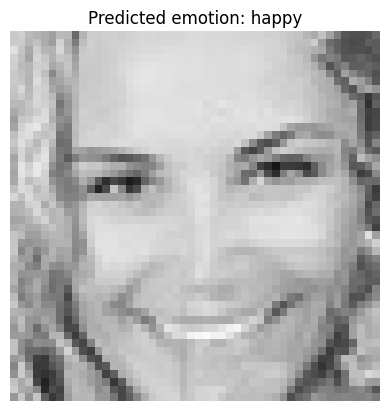

In [103]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(image)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Predicted emotion: " + label[pred.argmax()])
plt.axis("off")